In [1]:
import sys
import torch
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler

sys.path.append('../model')
sys.path.append('../helpers/')

from edit import *
from helpers.plots import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from sklearn.linear_model import LinearRegression
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

/home/aas926/.local/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/aas926/.local/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias u

,pid,cid,code,x_next,t_next,s_next,mu,log_var,split,run_id
2721920,12836605,30,TC,216.0,1758.929810,0,226.464279,5.775604,test,87345aff
2721921,17562616,7,RDW,13.8,1.045833,1,14.178661,-2.459845,test,87345aff
2721922,19757969,12,CL,99.0,330.961121,1,101.968681,1.379001,test,87345aff
2721923,17896400,9,MCV,102.0,358.127075,0,102.197189,1.396440,test,87345aff
2721924,11540420,18,CA,9.0,5.402778,1,8.982261,-2.418557,test,87345aff


In [8]:
MODEL = 'abe67471'
RUN_IDS = ['ARIMA', 'Mean', 'last', MODEL]
SOURCE = BASE = 'combined'
METRICS_TO_AGG = ['MAE', 'MAPE', 'R2', 'MSE']
EXCLUDE_CODES = ['CRP', 'GGT', 'LDH']
LOG_DIR = '/n/data1/hms/dbmi/manrai/aashna/NORMA/model/logs/'

results, state_col = load_counterfactual_predictions([MODEL], LOG_DIR)
results = results[results[state_col]==1]
patients_code_pairs = results[['pid', 'cid']].drop_duplicates().values.tolist()
print(results)


               pid  cid code      x_next       t_next  s_next  state  \
3075032   13281616    2  MCH   22.900000  2539.125000       0   True   
3075033   17234528   14  BUN   26.000000  2095.690918       0   True   
3075034   10787013   32  LDL  113.000000  2056.944336       1   True   
3075035  115968365   21  AST   36.000000  2023.008301       1   True   
3075036   12700221   32  LDL   58.000000  2146.073730       1   True   
...            ...  ...  ...         ...          ...     ...    ...   
3843727   16401902    5  PLT  364.000000     5.200695       1   True   
3843728   18640073    8  WBC    7.000000   323.999298       1   True   
3843729   11165060    0  HCT   24.799999    14.314584       0   True   
3843730   17983541    5  PLT  276.000000     3.996528       1   True   
3843731   18702681    7  RDW   15.800000   256.206940       0   True   

                 mu         std split    std_pred      var_pred    log_var  \
3075032   28.860006    0.603371  test    0.603371      0.

In [21]:
source = 'combined_sequences_v2'
test_features_path = f'../data/processed/{source}_test_features.csv'
seqs = f'../data/processed/{source}.pkl'
print('Loading test sequences')
if not os.path.exists(test_features_path):
    with open(seqs, 'rb') as f:
        test_seq = pickle.load(f)
    print('Done loading test sequences')
    patients_code_set = set(map(tuple, patients_code_pairs))
    # Use list comprehension only if test_seq is a list, otherwise try a more efficient approach if test_seq is large
    # Use filter for a lazy iterator
    test_seq = list(filter(lambda seq: (seq['pid'], seq['cid']) in patients_code_set, test_seq))
    # get sequences in ehrshot only
    
    print('Done loading test sequences')
    test_features = get_features(test_seq).sort_values('code')
    test_features.to_csv(test_features_path, index=False)
    print('Done extracting features')
else:
    test_features = pd.read_csv(test_features_path)

# ---------------------------------------------------
# Merge features with counterfactual predictions
# ---------------------------------------------------
ehrshot = '../data/processed/EHRSHOT_processed_df.csv'
ehrshot = pd.read_csv(ehrshot)
display(ehrshot.head())

df = test_features.merge(results, on=['pid', 'code'], how='inner')
# df = df.merge(ehrshot, left_on=['pid', 'code'], right_on=['subject_id', 'test_name'], how='inner')

print(df.head())


Loading test sequences


,source,subject_id,sex,test_name,time,numeric_value,time_delta
0,ehrshot,115967095,1,BUN,2008-10-08 01:11:00,16.0,0.000000
1,ehrshot,115967095,1,BUN,2008-10-08 08:10:00,13.0,0.290972
2,ehrshot,115967095,1,BUN,2008-10-09 05:05:00,11.0,1.162500
3,ehrshot,115967095,1,BUN,2008-10-10 06:05:00,10.0,2.204167
4,ehrshot,115967095,1,BUN,2008-10-11 06:40:00,10.0,3.228472


         pid code   mu_true  var_true  var_true_normal  n_obs  t_delta_last  \
0   13650860  A1C  5.729630  0.524307         0.133542     27     20.044922   
1  115967905  A1C  5.316667  0.044722         0.018400      6     27.984009   
2   13684732  A1C  5.616667  0.034722         0.015556      6    121.969482   
3   10664271  A1C  6.125000  0.066875         0.000000      4    123.118042   
4   10642727  A1C  5.200000  0.516667         0.382222      6     69.888916   

    t_duration  n_normal  p_normal  ...       t_next  s_next  state        mu  \
0  4213.125000        12  0.444444  ...  4279.197266       1   True  4.949227   
1  1099.317383         5  0.833333  ...  1525.039551       1   True  5.321332   
2  2509.995850         3  0.500000  ...  2713.920166       1   True  5.473282   
3   495.072906         0  0.000000  ...   616.183350       1   True  5.538080   
4  3733.052002         3  0.500000  ...  4199.131836       1   True  4.547006   

        std  split  std_pred  var_pred

In [23]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler

def _lasso(X, y, alpha=0.05, verbose=True):
    m = Lasso(alpha=alpha); m.fit(X, y)
    # Standard errors are not straightforward for Lasso; returning None
    return m.score(X, y), dict(zip(X.columns, m.coef_)), None

def _lin_reg(X, y):
    m = LinearRegression(); m.fit(X, y)
    # Compute standard errors for coefficients
    if hasattr(m, "coef_"):
        pred = m.predict(X)
        n, p = X.shape
        resid = y - pred
        s2 = np.sum(resid**2) / (n - p)
        # Add bias column for intercept if fit_intercept (default True)
        X_mat = X.values if isinstance(X, pd.DataFrame) else X
        if m.fit_intercept:
            X_mat = np.column_stack([np.ones(X_mat.shape[0]), X_mat])
        else:
            X_mat = np.array(X_mat)
        try:
            XtX_inv = np.linalg.inv(X_mat.T @ X_mat)
            # Don't include intercept std error if fit_intercept
            se = np.sqrt(np.diag(s2 * XtX_inv))
            if m.fit_intercept:
                se = se[1:]  # Skip intercept
            std_err = dict(zip(X.columns, se))
        except Exception as e:
            std_err = None
    else:
        std_err = None
    return m.score(X, y), dict(zip(X.columns, m.coef_)), std_err

def _ridge(X, y, alpha=0.05, verbose=True):
    m = Ridge(alpha=alpha); m.fit(X, y)
    # Standard errors for Ridge are not trivial; returning None
    return m.score(X, y), dict(zip(X.columns, m.coef_)), None

def _build_X(df, features, code_col='code', scale=True, drop_first=True):
    X = df[features].copy()
    for c in [c for c in ['n_obs','t_delta_last','t_duration'] if c in X.columns]:
        X[c] = np.log1p(X[c])
    dummies = pd.get_dummies(df[code_col].astype(str), prefix='code', drop_first=drop_first)
    if scale:
        scaler = StandardScaler()
        X[X.columns] = scaler.fit_transform(X[X.columns])
    inter = {f'{f}__x__{d}': X[f].values * dummies[d].values
             for f in X.columns for d in dummies.columns}
    X_all = pd.concat([X, dummies, pd.DataFrame(inter, index=X.index)], axis=1)
    return X_all

def _build_y(df, target="std", standardize_target=False):
    if target == "std":
        base = df['std']
        y = np.where(base>0, np.log(base), np.nan)
    elif target == "log_var":
        base = df['var_true']
        y = np.where(base>0, np.log(base), np.nan)
    elif target == "var":
        y = df['var_true'].to_numpy()
    else:
        raise ValueError("Unknown target")
    y = pd.Series(y, index=df.index)
    if standardize_target:
        mu = y.mean(skipna=True); sd = y.std(ddof=0, skipna=True) or 1.0
        y = (y - mu) / (sd if sd!=0 and np.isfinite(sd) else 1.0)
    return y

def fit_model_pooled(df, model, features, code_col='code',
                     scale=True, alpha=0.05, target="log_var",
                     standardize_target=True, drop_first=True):
    X = _build_X(df, features=features, code_col=code_col, scale=scale, drop_first=drop_first)
    y = _build_y(df, target=target, standardize_target=standardize_target).rename('y')

    data = pd.concat([X, y], axis=1).replace([np.inf, -np.inf], np.nan).dropna(axis=0)
    Xc, yc = data.drop(columns=['y']), data['y']

    if model.__name__ == '_lasso':
        r2, coeffs, std_err = _lasso(Xc, yc, alpha=alpha)
    elif model.__name__ == '_ridge':
        r2, coeffs, std_err = _ridge(Xc, yc, alpha=alpha)
    else:
        r2, coeffs, std_err = model(Xc, yc)

    out = {'model': model.__name__, 'cid': 'ALL', 'scale': scale, 'r2': r2, 'std_err': std_err,
           'n_fit': len(yc), 'n_dropped': len(y)-len(yc)}
    out.update(coeffs)
    return out, yc

def fit_model_per_code(df, model, features, code_col='code',
                      scale=True, alpha=0.05, target="log_var",
                      standardize_target=True, drop_first=True):
    results = []
    y_dict = {}
    code_vals = df[code_col].unique()
    for code in code_vals:
        df_sub = df[df[code_col] == code]
        if len(df_sub) < 3:  # skip codes with too few samples
            continue
        try:
            out, y = fit_model_pooled(
                df_sub, model, features, code_col=code_col,
                scale=scale, alpha=alpha, target=target,
                standardize_target=standardize_target, drop_first=drop_first
            )
            out['cid'] = code
            results.append(out)
            y_dict[code] = y
        except Exception as e:
            print(f"Error fitting {code}: {e}")
    return results, y_dict

# Example usage:
base_feats = ['true_cv'] #,  'n_obs', 'p_normal', 't_delta_last', 't_duration', 'mu_x'] 
# # Fit for pooled/all codes
# pooled_results, pooled_y = fit_model_pooled(
#     df, _lin_reg, features=base_feats, code_col='code',
#     scale=True, alpha=0.05, target="log_var",
#     standardize_target=True, drop_first=True
# )

# Fit per code
per_code_results, per_code_ys = fit_model_per_code(
    df, _lin_reg, features=base_feats, code_col='code',
    scale=True, alpha=0.05, target="log_var",
    standardize_target=False, drop_first=True
)
print(per_code_results)

#plot_per_code_coefficients(per_code_results, base_feats)

# per_code_results_var, per_code_ys_var = fit_model_per_code(
#     df, _lin_reg, features=base_feats, code_col='code',
#     scale=True, alpha=0.05, target="var",
#     standardize_target=False, drop_first=True
# )

per_code_results_log_var, per_code_ys_log_var = fit_model_per_code(
    df, _lin_reg, features=base_feats, code_col='code',
    scale=True, alpha=0.05, target="log_var",
    standardize_target=True, drop_first=True
)
print(per_code_results_log_var)

# plot_per_code_coefficients(per_code_results_log_var, base_feats)

# per_code_results_log_var, per_code_ys_log_var = fit_model_per_code(
#     df, _lin_reg, features=base_feats, code_col='code',
#     scale=True, alpha=0.05, target="var",
#     standardize_target=True, drop_first=True
# )
# plot_per_code_coefficients(per_code_results_log_var, base_feats)


[{'model': '_lin_reg', 'cid': 'A1C', 'scale': True, 'r2': 0.8052468984995294, 'std_err': {'true_cv': 0.04320030029229408}, 'n_fit': 156, 'n_dropped': 0, 'true_cv': 1.0936414293081693}, {'model': '_lin_reg', 'cid': 'ALB', 'scale': True, 'r2': 0.8150613291444848, 'std_err': {'true_cv': 0.020345825198788393}, 'n_fit': 676, 'n_dropped': 1, 'true_cv': 1.109707378051845}, {'model': '_lin_reg', 'cid': 'ALP', 'scale': True, 'r2': 0.7765137154013688, 'std_err': {'true_cv': 0.024480448018177097}, 'n_fit': 1086, 'n_dropped': 0, 'true_cv': 1.5030843687870235}, {'model': '_lin_reg', 'cid': 'ALT', 'scale': True, 'r2': 0.6608586228077153, 'std_err': {'true_cv': 0.02663094447932575}, 'n_fit': 1422, 'n_dropped': 1, 'true_cv': 1.4013528429601487}, {'model': '_lin_reg', 'cid': 'AST', 'scale': True, 'r2': 0.7349313585715969, 'std_err': {'true_cv': 0.023575829111246}, 'n_fit': 1511, 'n_dropped': 0, 'true_cv': 1.5254559166794663}, {'model': '_lin_reg', 'cid': 'BUN', 'scale': True, 'r2': 0.6331344171137241, 

In [5]:

# Convert per-code results to DataFrame
df_coeff = pd.DataFrame(per_code_results_log_var)
df_coeff['cv_coeff'] = df_coeff['cv']
df_coeff['cv_stderr'] = df_coeff['std_err'].apply(lambda d: d.get('cv', np.nan) if isinstance(d, dict) else np.nan)
df_coeff['r2'] = pd.to_numeric(df_coeff['r2'], errors="coerce")
df_coeff = df_coeff.sort_values('r2', ascending=False).reset_index(drop=True)

# Use a vibrant and colorblind-friendly seaborn palette for better look
cmap = sns.color_palette("mako", as_cmap=True)# Viridis is perceptually uniform and colorblind-friendly
# list other palettes
# "viridis", "plasma", "inferno", "magma", "cividis", "rocket", "mako", "turbo"
fig, ax = plt.subplots(figsize=(10, 2.5))

# Scatter plot with r2 on y-axis, coefficient value shown as point color
scatter = ax.scatter(
    np.arange(len(df_coeff)),
    df_coeff["r2"],
    c=df_coeff["cv_coeff"],
    cmap=cmap,
    s=60,
    edgecolors="none",
    zorder=2
)

# Axis labels
ax.set_ylabel("Log Variance Explained (R²)", fontsize=11)
xlabels = df_coeff["cid"].tolist()
ax.set_xticks(np.arange(df_coeff.shape[0]))
ax.set_xticklabels(xlabels, rotation=45, ha="right")
ax.tick_params(axis='x', length=0)

# y axis minor ticks and grid
ax.grid(True, axis='y', which='major', linestyle='-', color="#e0e0e0", linewidth=0.7, alpha=0.85)
ax.grid(True, axis='y', which='minor', linestyle=':', color="#e0e0e0", linewidth=0.5, alpha=0.6)
ax.minorticks_on()

# Colorbar: shows the CV coefficient
cb = plt.colorbar(scatter, ax=ax, pad=0.015)
cb.set_label('CV Effect Size', weight="normal", fontsize=11)

plt.show()



NameError: name 'per_code_results_log_var' is not defined

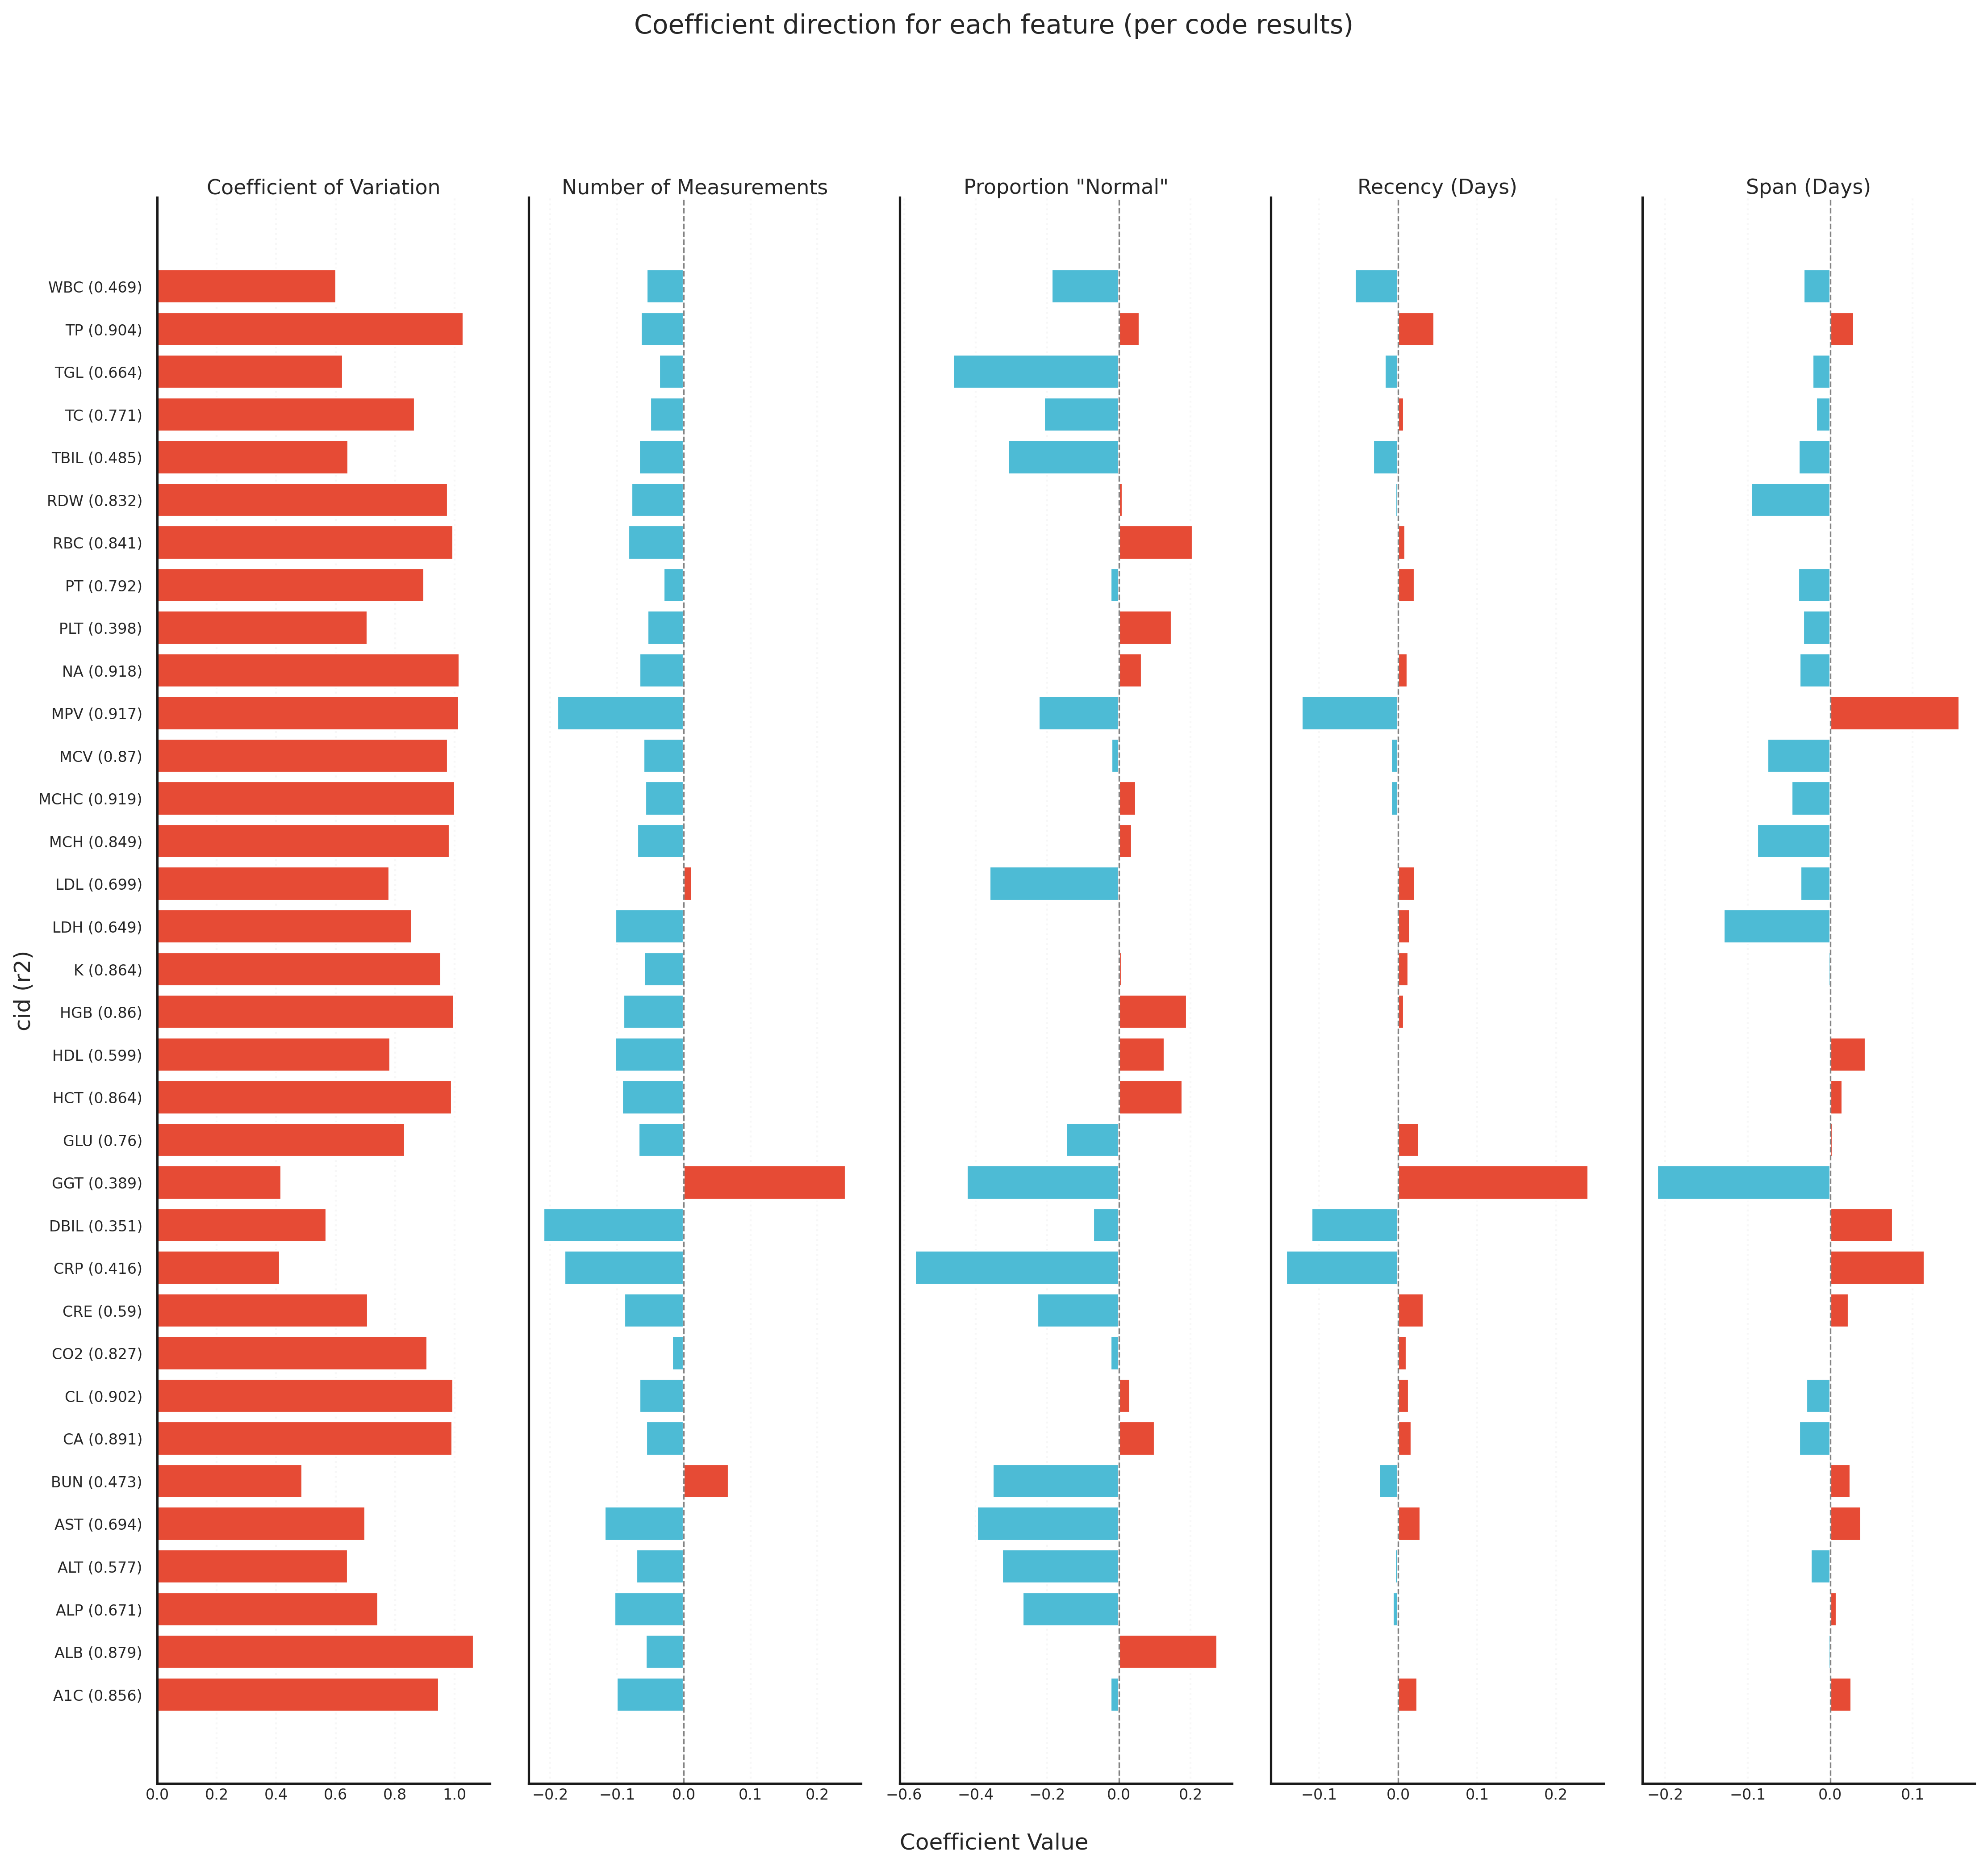

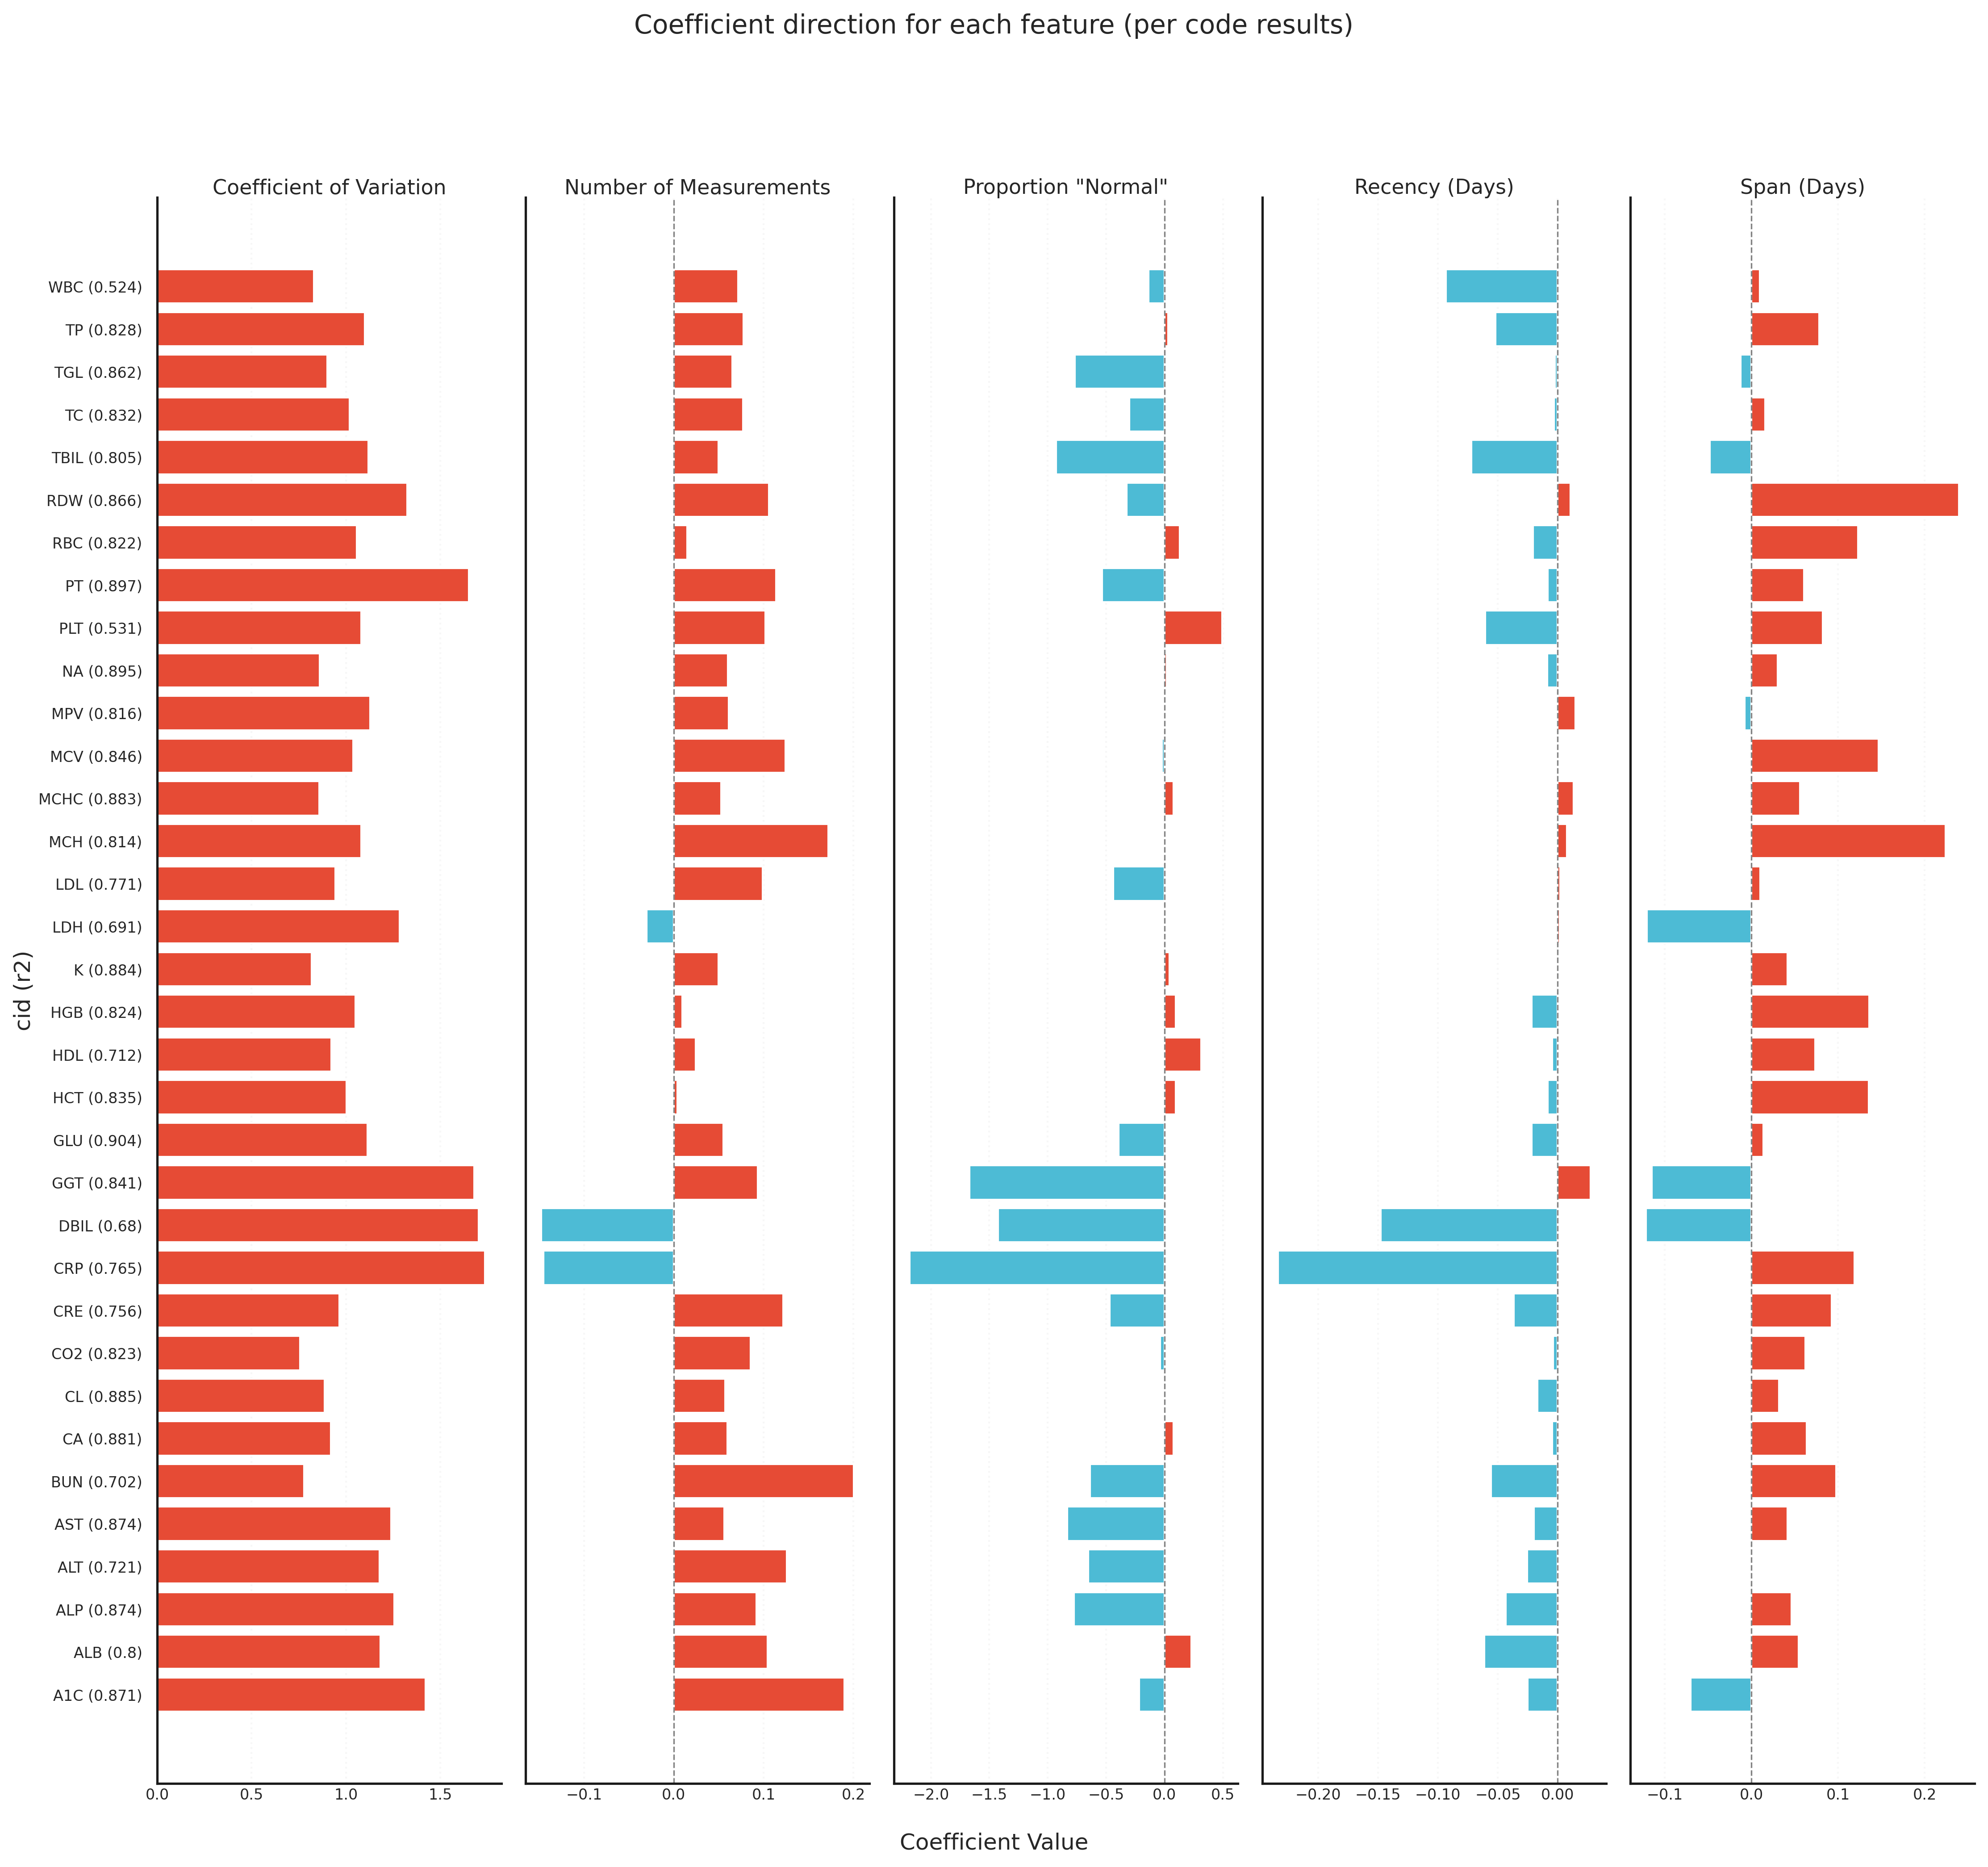

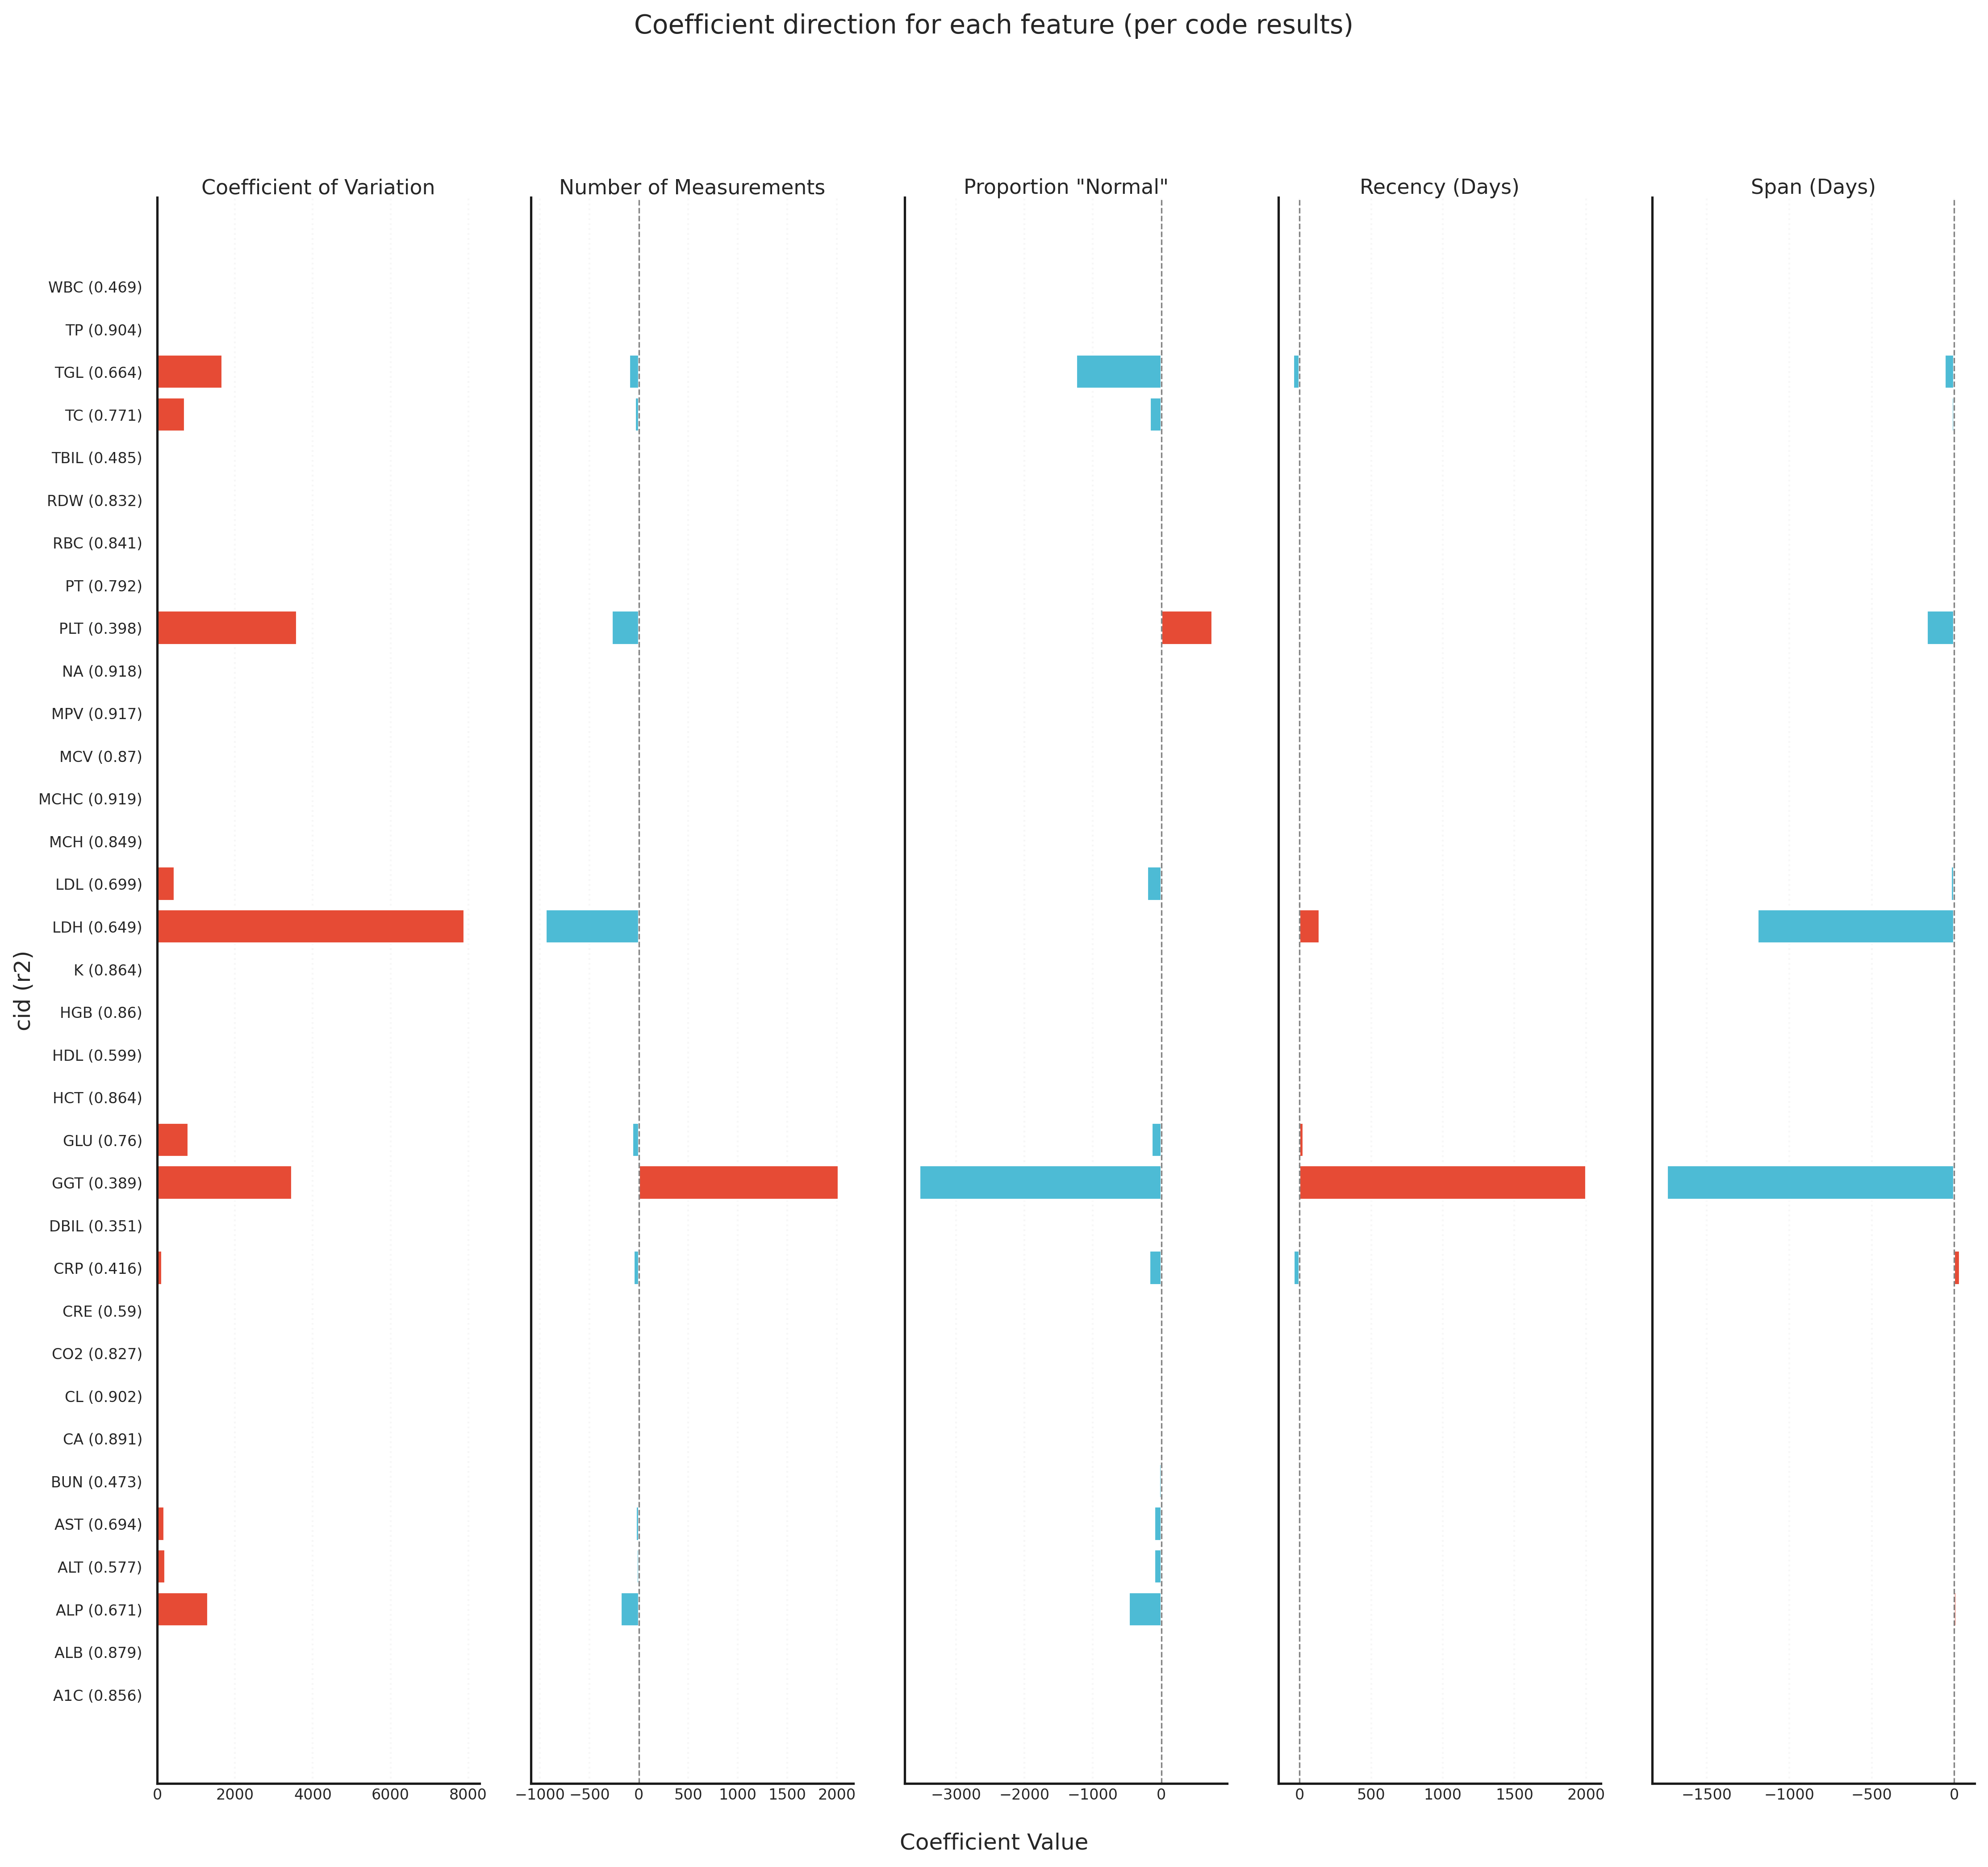

In [58]:
def plot_per_code_coefficients(
    per_code_results,
    base_feats,
    feature_title_map=None,
    fig_title='Coefficient direction for each feature (per code results)'
):
    """
    Bar graph of coefficients for each code (cid) using per_code_results.

    Args:
        per_code_results (list or DataFrame): List of dicts or DataFrame with per-code regression results.
        base_feats (list): List of feature names to plot.
        feature_title_map (dict, optional): Mapping from feature name to pretty title.
        fig_title (str, optional): Title for the figure.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    if isinstance(per_code_results, list):
        per_code_df = pd.DataFrame(per_code_results)
    else:
        per_code_df = per_code_results.copy()

    if feature_title_map is None:
        feature_title_map = {
            'cv': 'Coefficient of Variation',
            'log_cv': 'Log CV (All)',
            'cv_normal': 'CV (Normal Only)',
            'log_cv_normal': 'Log CV (Normal Only)',
            'n_obs': 'Number of Measurements',
            't_delta_last': 'Recency (Days)',
            't_duration': 'Span (Days)',
            'p_normal': 'Proportion "Normal"',
            'var_x': 'Variance (All)',
            'var_x_normal': 'Variance (Normal Only)',
            'mu_x': 'Mean (All)',
            'mu': 'Mean (All)',
            'std': 'Std Dev (All)',
            'code': 'Lab Code',
            'x_var_t_delta': 'Variance × Recency',
            'x_var_t_duration': 'Variance × Span',
            'x_var_n_normal': 'Variance × #Normal',
            't_delta_t_duration': 'Recency × Span',
            't_delta_n_normal': 'Recency × #Normal',
            't_duration_n_normal': 'Span × #Normal'
        }

    # Sort by cid for nicer plots
    if 'cid' in per_code_df.columns:
        plot_df = per_code_df.sort_values('cid').copy()
    else:
        plot_df = per_code_df.copy()

    # Format y-axis as cid (r2), if available
    cids = plot_df['cid'].astype(str).values if 'cid' in plot_df.columns else plot_df.index.astype(str)
    if 'r2' in plot_df.columns:
        r2s = plot_df['r2'].round(3).astype(str).values
        y_labels = [f"{cid} ({r2})" for cid, r2 in zip(cids, r2s)]
    else:
        y_labels = list(cids)

    fig, axes = plt.subplots(1, len(base_feats), figsize=(3*len(base_feats), max(6, 0.4*len(y_labels))), sharey=True)

    if len(base_feats) == 1:
        axes = [axes]
    for i, feature in enumerate(base_feats):
        if feature not in plot_df.columns:
            continue  # Skip features not present
        betas = plot_df[feature].values
        colors = ['#E64B35' if b > 0 else '#4DBBD5' for b in betas]
        axes[i].barh(y_labels, betas, color=colors)
        axes[i].axvline(0, color='#333', linestyle='--', lw=0.8, alpha=0.6)
        if i == 0:
            axes[i].set_ylabel("cid (r2)" if 'r2' in plot_df.columns else "cid")
        axes[i].set_yticklabels(y_labels, fontsize=8)
        axes[i].set_title(feature_title_map.get(feature, feature), loc='center', fontsize=11, pad=2)
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].grid(axis='x', linestyle=':', alpha=0.15)
        axes[i].tick_params(axis="x", labelsize=8)
    fig.supxlabel('Coefficient Value', fontsize=12)
    fig.suptitle(fig_title, y=1.02, fontsize=14)
    handles = [
        plt.Rectangle((0,0),1,1, facecolor='#E64B35', label='Positive'),
        plt.Rectangle((0,0),1,1, facecolor='#4DBBD5', label='Negative'),
    ]
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# Example usage:
plot_per_code_coefficients(per_code_results_log_var, base_feats)
plot_per_code_coefficients(per_code_results, base_feats)
plot_per_code_coefficients(per_code_results_var, base_feats)


In [ ]:
df

In [6]:
df_f = df.copy().query('code not in @exclude')
feature  = base_feats + ['code']
t_reg = []
t_reg.append(fit_model(df_f, _lin_reg, features=feature))
t_reg.append(fit_model(df_f, _ridge, features=feature))

t_reg = pd.DataFrame(t_reg)
display(t_reg)

df_f = df.copy().query('code not in @exclude')
feature  = base_feats 
t_reg = []
t_reg.append(fit_model(df_f, _lin_reg, features=feature))
t_reg.append(fit_model(df_f, _ridge, features=feature))

t_reg = pd.DataFrame(t_reg)
display(t_reg)

# Fixed-effects pooled model: OLS with code dummies (C(code))
import numpy as np
import statsmodels.formula.api as smf

# Use df_f instead of df2
df2 = df_f.copy()

# Transform skewed positives
for col in ['n_obs', 't_delta_last', 't_duration']:
    if col in df2.columns:
        df2[col] = np.log1p(np.clip(df2[col], a_min=0, a_max=None))

# Standardize numeric features globally (not the dummies)
for col in base_feats:
    if col in df2.columns:
        s = df2[col].std()
        df2[col] = (df2[col] - df2[col].mean()) / (s if (s and not np.isnan(s) and s != 0) else 1.0)

df2['log_std'] = np.log(df2['std'])

formula = 'log_std ~ ' + ' + '.join([*base_feats, 'C(code)'])
ols_fit = smf.ols(formula, data=df2).fit()

print('OLS R^2:', round(ols_fit.rsquared, 4))
display(ols_fit.summary())

# Better for many/unbalanced codes: Mixed-effects with random intercept per code
# Shrinks per-code effects and typically improves generalization.
import statsmodels.formula.api as smf
import numpy as np

# Use df_f instead of df3
df3 = df_f.copy()

for col in ['n_obs', 't_delta_last', 't_duration']:
    if col in df3.columns:
        df3[col] = np.log1p(np.clip(df3[col], a_min=0, a_max=None))

for col in base_feats:
    if col in df3.columns:
        s = df3[col].std()
        df3[col] = (df3[col] - df3[col].mean()) / (s if (s and not np.isnan(s) and s != 0) else 1.0)

df3['log_std'] = np.log(df3['std'])

mix_fit = smf.mixedlm("log_std ~ " + " + ".join(base_feats), data=df3, groups=df3["code"]).fit(method="lbfgs", reml=True)

# Simple pseudo-R^2 (marginal approximation)
pseudo_r2 = 1 - (mix_fit.scale / np.var(df3['log_std'], ddof=1))
print('MixedLM pseudo-R^2 (marginal):', round(float(pseudo_r2), 4))
display(mix_fit.summary())

NameError: name 'df' is not defined